In [1]:
from dask.distributed import Client, progress
import dask

In [13]:
from dask.distributed import Client, progress
# 1) Force local threads scheduler (avoids pickling to workers)
dask.config.set(scheduler="threads")
# dask.config.set(temporary_directory='/home/kheimes2/tmp/dask-worker/')

In [3]:
client = Client()  # set up local cluster on your laptop
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37305,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36025,Total threads: 1
Dashboard: http://127.0.0.1:39597/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:44629,


In [4]:
import xarray as xr
import pandas as pd
import numpy as np

In [8]:
# base_url = 'https://thredds.rda.ucar.edu/thredds/dodsC/files/g/ds633.1_nc/e5.moda.an.sfc/'
# base_url2 = '/e5.moda.an.sfc.128_167_2t.ll025sc.'
# base_url3 = '.nc'

# # period of interest
# pr = pd.date_range(start='1979-01',end='2022-12', freq='AS')

# file_list=[]
# for dt in pr:
#     # get recent year and month
#     year = dt.strftime('%Y')
#     month = dt.strftime('%Y%m%d%H')
#     month2 = (dt + pd.DateOffset(months=11)).strftime('%Y%m%d%H')

#     # build complete file name
#     single_file=(base_url+year+base_url2+month+'_'+month2+base_url3)
#     file_list.append(single_file)

base_url = 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/'
base_url2 = '/e5.moda.an.sfc.128_167_2t.ll025sc.'
base_url3 = '.nc'

# period of interest
pr = pd.date_range(start='1979-01',end='2022-12', freq='YS')

file_list=[]
for dt in pr:
    # get recent year and month
    year = dt.strftime('%Y')
    month = dt.strftime('%Y%m%d%H')
    month2 = (dt + pd.DateOffset(months=11)).strftime('%Y%m%d%H')

    # build complete file name
    single_file=(base_url+year+base_url2+month+'_'+month2+base_url3)
    file_list.append(single_file)

In [9]:
file_list

['https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1979/e5.moda.an.sfc.128_167_2t.ll025sc.1979010100_1979120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1980/e5.moda.an.sfc.128_167_2t.ll025sc.1980010100_1980120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1981/e5.moda.an.sfc.128_167_2t.ll025sc.1981010100_1981120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1982/e5.moda.an.sfc.128_167_2t.ll025sc.1982010100_1982120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1983/e5.moda.an.sfc.128_167_2t.ll025sc.1983010100_1983120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1984/e5.moda.an.sfc.128_167_2t.ll025sc.1984010100_1984120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/1985/e5.moda.an.sfc.128_167_2t.ll025sc.1985010100_1985120100.nc',
 'https://osdf-data.gdex.ucar.edu/ncar/gdex/d633001/e5.moda.an.sfc/19

In [11]:
# ds = xr.open_mfdataset(file_list, parallel=True,chunks={'time': '50MB'})

#cached = [f"simplecache::{u}" for u in file_list]
ds = xr.open_mfdataset(
#    cached,
    file_list,
    engine="h5netcdf",         # or "h5netcdf"
    combine="by_coords",
    chunks={"time": 12},      # modest time chunks
    parallel=False,           # <- important: don't delay opens
  #  backend_kwargs={"storage_options": {"simplecache": {"cache_storage": "./_gdex_cache"}}},
)

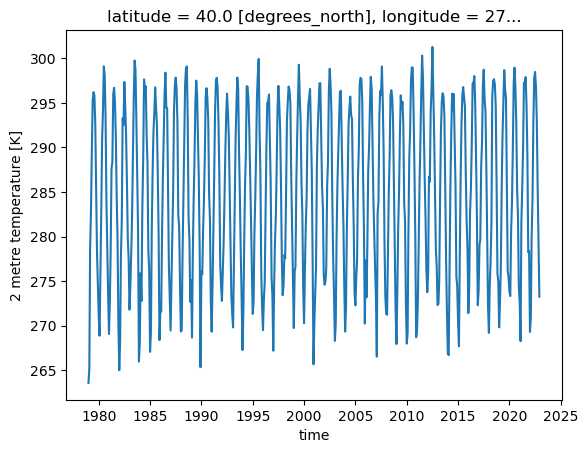

In [14]:
ds['VAR_2T'].sel(latitude=40., longitude=360-88., method='nearest').plot()

In [15]:
client.close()